In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
import seaborn as sns
import h5py

In [2]:
mean_diag = np.load("results/allchan_diag/means.npy")
norm_rmses_diag = np.load("results/allchan_diag/norm_rmses.npy")
rmses_diag = np.load("results/allchan_diag/rmses.npy")
stds_diag = np.load("results/allchan_diag/stds.npy")

mean_nondiag = np.load("results/allchan_nondiag/means.npy")
norm_rmses_nondiag = np.load("results/allchan_nondiag/norm_rmses.npy")
rmses_nondiag = np.load("results/allchan_nondiag/rmses.npy")
stds_nondiag = np.load("results/allchan_nondiag/stds.npy")

In [31]:
t200 = np.load("data/time_200.npy")

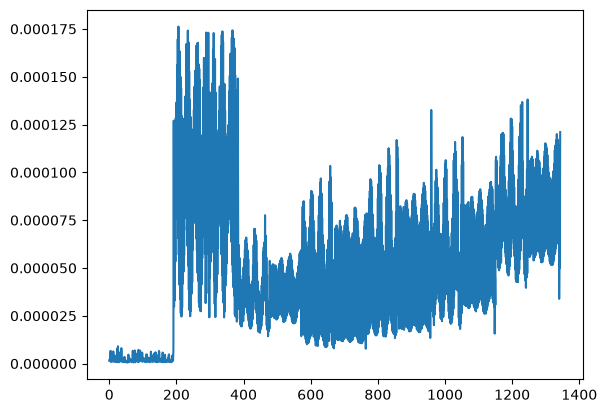

In [7]:
plt.plot(rmses_nondiag)

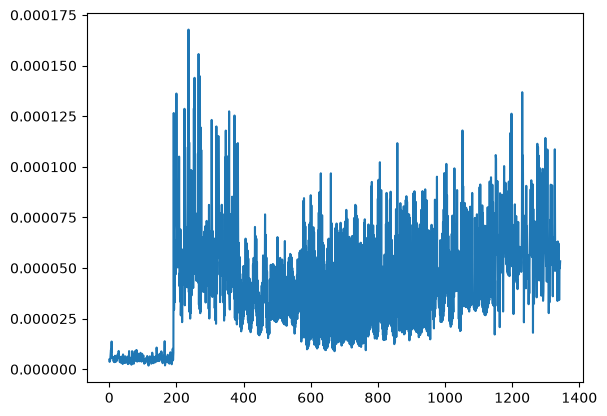

In [8]:
plt.plot(rmses_diag)

In [9]:
d_true = np.load("data/true_allchan_200.npy")
d = np.load("data/traces_allchan_200.npy")

In [10]:
def compare(y_mean, y_std, x, y_true, y_noise, norm_rmse, compare="true"):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[-50:]-np.mean(y_noise[-50:]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Abs_Res($t_{{peak}}$): {abs_res_peak:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")
    plt.show()

    return y_mean, y_std, diff, abs_res

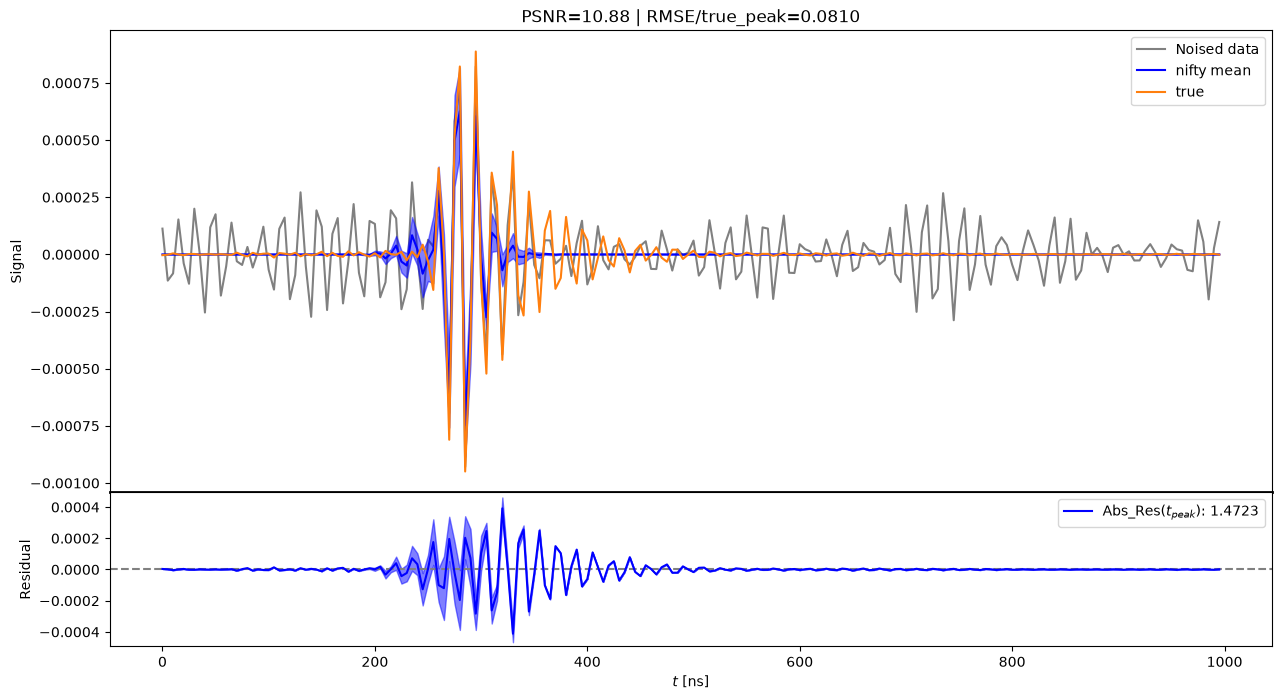

In [194]:
# idx = np.random.randint(0,len(mean_nondiag))
# print(idx)
idx = 228
res=compare(mean_nondiag[idx], stds_nondiag[idx], t200, d_true[idx], d[idx], norm_rmses_nondiag[idx], compare="true")

In [172]:
good_cond = np.where(norm_rmses_diag < 0.1)
good_means_diag = mean_diag[good_cond]

good_cond = np.where(norm_rmses_nondiag < 0.1)
good_means_nondiag = mean_nondiag[good_cond]

In [175]:
good_cond

(array([ 208,  228,  232,  258,  297,  313,  331,  341,  363,  369, 1170]),)

In [173]:
len(good_means_diag), len(good_means_nondiag)

(215, 11)

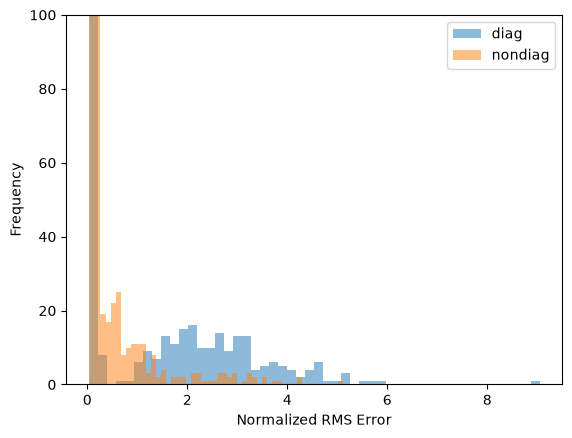

In [29]:
plt.hist(norm_rmses_diag, bins=50, alpha=0.5, label="diag")
plt.hist(norm_rmses_nondiag, bins=50, alpha=0.5, label="nondiag")
plt.xlabel("Normalized RMS Error")
plt.ylabel("Frequency")
plt.legend()
plt.ylim(0,100)
plt.show()

In [13]:
# Calculate SNR and UWR
def snr_uwr(y_true, y_noise, y_mean, y_std):
    snr = np.max(np.abs(y_true), axis=1)/np.sqrt(np.mean(np.square(y_noise[:, -50:]), axis=1))
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.arange(len(abs_res)), np.argmax(np.abs(y_true), axis=1)]

    return snr, abs_res_peak

In [14]:
snr_diag, uwr_diag = snr_uwr(d_true, d, mean_diag, stds_diag)
snr_nondiag, uwr_nondiag = snr_uwr(d_true, d, mean_nondiag, stds_nondiag)

/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_16864/3488436193.py:5: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


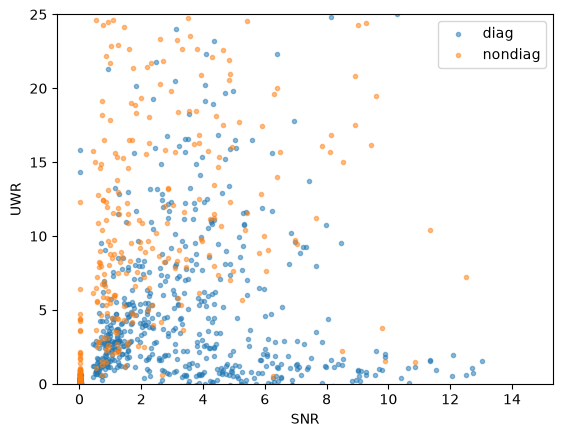

In [24]:
plt.scatter(snr_diag, uwr_diag, label="diag", alpha=0.5, marker=".")
plt.scatter(snr_nondiag, uwr_nondiag, label="nondiag", alpha=0.5, marker=".")
plt.xlabel("SNR")
plt.ylabel("UWR")
plt.legend()
plt.ylim(0, 25)
plt.show()

In [30]:
def compare2(mean1, std1, mean2, std2, x, y_true, y_noise, norm_rmse1, norm_rmse2):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[-50:]-np.mean(y_noise[-50:]))))
    # calculate statistical measurements
    diff = mean1 - y_true
    abs_res1 = diff/std1
    abs_res2 = diff/std2
    abs_res_peak1 = abs_res1[np.argmax(np.abs(y_true))]
    abs_res_peak2 = abs_res2[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray") # Initial data with noise
    axes[0].plot(x, y_true, label="true", c="chocolate") # true signal without noise
    axes[0].fill_between(x, mean1-std1, mean1+std1, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, mean1, label=f"Diagonal Cov", c="blue") # Mean posterior
    axes[0].fill_between(x, mean2-std2, mean2+std2, color="red", alpha=0.5) # one sigma posterior
    axes[0].plot(x, mean2, label=f"Non-Diagonal Cov", c="red") # Mean posterior

    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-std1, diff+std1, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Abs_Res($t_{{peak}}$): {abs_res_peak1:.4f}")
    axes[1].fill_between(x, diff-std2, diff+std2, color="red", alpha=0.5)
    axes[1].plot(x, diff, c="red", label=rf"Abs_Res($t_{{peak}}$): {abs_res_peak2:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse1:.4f}, {norm_rmse2:.4f}")
    plt.show()

    return abs_res1, abs_res2

604


/var/folders/n1/k8knqyrj56g68f01q_stqk840000gn/T/ipykernel_16864/1418655677.py:7: RuntimeWarning: divide by zero encountered in divide
  abs_res2 = diff/std2


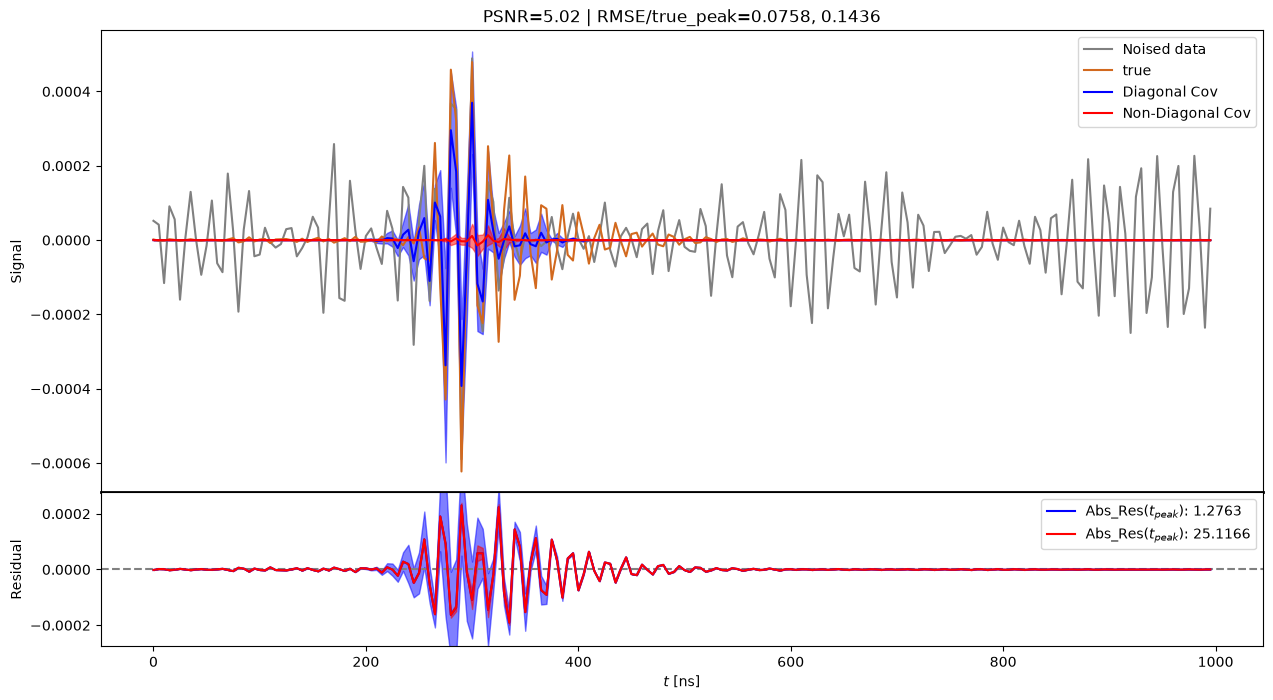

In [82]:
idx=np.random.randint(0, len(mean_diag))
print(idx)
res = compare2(mean_diag[idx], stds_diag[idx], mean_nondiag[idx], stds_nondiag[idx], t200, d_true[idx], d[idx], norm_rmses_diag[idx], norm_rmses_nondiag[idx] )

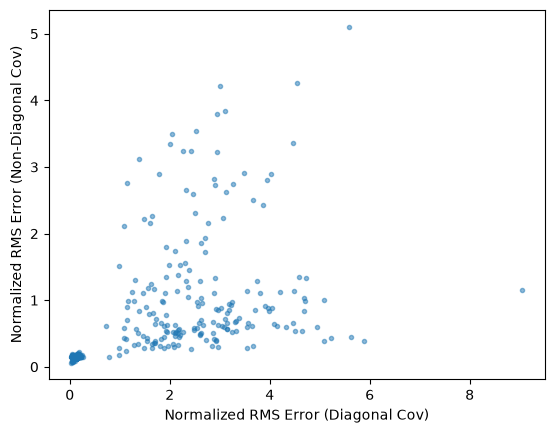

In [78]:
plt.scatter(norm_rmses_diag, norm_rmses_nondiag, alpha=0.5, marker=".")
plt.xlabel("Normalized RMS Error (Diagonal Cov)")
plt.ylabel("Normalized RMS Error (Non-Diagonal Cov)")
plt.show()

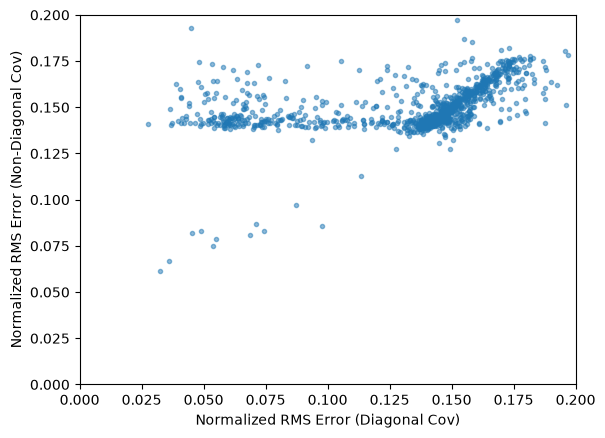

In [45]:
plt.scatter(norm_rmses_diag, norm_rmses_nondiag, alpha=0.5, marker=".")
plt.xlabel("Normalized RMS Error (Diagonal Cov)")
plt.ylabel("Normalized RMS Error (Non-Diagonal Cov)")
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.show()